# FIFA World Cup 2026 — Analytic Task
## Creative Output: Assists per 90 Minutes by Position (Midfielders vs Forwards)

**Analytic question:** On average, do midfielders register significantly more assists per 90 minutes than forwards at the 2026 FIFA World Cup? Players who never played (0 minutes) are excluded.

**Data source:** FBref.com — 2026 World Cup, Player Standard Stats table (exported manually via FBref's "Get table as CSV" tool, since FBref blocks automated scraping).

## 1. Setup

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

RAW_FILE = "player_standard_raw.csv"
SAMPLE_SIZE = 60
RANDOM_SEED = 42

## 2. Data Wrangling


In [2]:
with open(RAW_FILE, encoding="cp1252") as f:
    lines = [l.rstrip("\n").strip('"') for l in f]

header = lines[1].split(",")
data_rows = [l.split(",") for l in lines[2:] if l.strip()]
raw = pd.DataFrame(data_rows, columns=header)

# Keep first occurrence of duplicate-named columns
raw = raw.loc[:, ~raw.columns.duplicated(keep="first")]

df = raw[["Player", "Pos", "Squad", "90s", "Ast"]].copy()
df["90s"] = pd.to_numeric(df["90s"], errors="coerce")
df["Ast"] = pd.to_numeric(df["Ast"], errors="coerce")
df = df.dropna(subset=["90s", "Ast"])

# Primary position = first 2 characters of the Pos code
df["PrimaryPos"] = df["Pos"].str[:2]
df = df[df["PrimaryPos"].isin(["MF", "FW"])].copy()

# Exclude players who never played (0 minutes)
df = df[df["90s"] > 0].copy()
df["Ast_per90"] = df["Ast"] / df["90s"]

print(f"Population after wrangling: {len(df)} players "
      f"({(df['PrimaryPos']=='MF').sum()} MF, {(df['PrimaryPos']=='FW').sum()} FW)")
df.head()

Population after wrangling: 608 players (385 MF, 223 FW)


,Player,Pos,Squad,90s,Ast,PrimaryPos,Ast_per90
0,Brenden Aaronson,MF,us USA,0.8,0,MF,0.0
1,Thelo Aasgaard,MF,no Norway,1.0,0,MF,0.0
2,Hamza Abdelkarim,FW,eg Egypt,0.7,0,FW,0.0
8,Yusuf Abdurisag,FW,qa Qatar,1.1,0,FW,0.0
15,Elias Achouri,FWMF,tn Tunisia,0.5,0,FW,0.0


## 3. Data Preparation & Sampling


In [3]:
parts = []
for pos, g in df.groupby("PrimaryPos"):
    n_take = min(len(g), round(SAMPLE_SIZE * len(g) / len(df)))
    parts.append(g.sample(n=n_take, random_state=RANDOM_SEED))
sample = pd.concat(parts, ignore_index=True)

print(f"Sample drawn: n={len(sample)} "
      f"({(sample['PrimaryPos']=='MF').sum()} MF, {(sample['PrimaryPos']=='FW').sum()} FW)")
sample.head()

Sample drawn: n=60 (38 MF, 22 FW)


,Player,Pos,Squad,90s,Ast,PrimaryPos,Ast_per90
0,Mohanad Ali,FW,iq Iraq,0.1,0,FW,0.000000
1,Erling Haaland,FW,no Norway,5.2,0,FW,0.000000
2,Noa Lang,FWMF,nl Netherlands,0.1,0,FW,0.000000
3,Iliman Ndiaye,FW,sn Senegal,1.3,2,FW,1.538462
4,Alejandro Zendejas,FWMF,us USA,0.2,0,FW,0.000000


## 4. Descriptive Statistics

In [4]:
desc = sample.groupby("PrimaryPos")["Ast_per90"].agg(
    ["count", "mean", "std", "median", lambda x: x.quantile(.25), lambda x: x.quantile(.75)])
desc.columns = ["n", "mean", "sd", "median", "Q1", "Q3"]
desc.round(3)

,n,mean,sd,median,Q1,Q3
PrimaryPos,,,,,,
FW,22,0.095,0.333,0.0,0.0,0.0
MF,38,0.074,0.198,0.0,0.0,0.0


## 5. Inferential Statistics — Confidence Interval


In [5]:
mf = sample.loc[sample["PrimaryPos"] == "MF", "Ast_per90"]
fw = sample.loc[sample["PrimaryPos"] == "FW", "Ast_per90"]

n = len(mf)
mean, se = mf.mean(), mf.std(ddof=1) / np.sqrt(n)
ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

print(f"95% CI for population mean assists/90 among midfielders: "
      f"{mean:.3f}  [{ci_low:.3f}, {ci_high:.3f}]  (n={n})")

95% CI for population mean assists/90 among midfielders: 0.074  [0.009, 0.139]  (n=38)


## 6. Inferential Statistics — Two-Sample t-Test


In [6]:
t_stat, p_val = stats.ttest_ind(mf, fw, equal_var=False)

print(f"MF: n={len(mf)}, mean={mf.mean():.3f}, sd={mf.std(ddof=1):.3f}")
print(f"FW: n={len(fw)}, mean={fw.mean():.3f}, sd={fw.std(ddof=1):.3f}")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

verdict = "statistically significant" if p_val < 0.05 else "not statistically significant"
print(f"--> Difference is {verdict} at alpha = 0.05")

MF: n=38, mean=0.074, sd=0.198
FW: n=22, mean=0.095, sd=0.333
t = -0.269, p = 0.7897
--> Difference is not statistically significant at alpha = 0.05


## 7. Visualisation

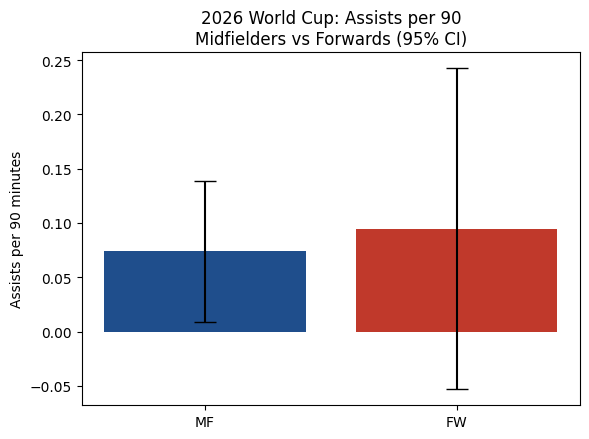

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
groups = ["MF", "FW"]
means = [mf.mean(), fw.mean()]
errs = [mf.std(ddof=1) / np.sqrt(len(mf)) * stats.t.ppf(0.975, len(mf) - 1),
        fw.std(ddof=1) / np.sqrt(len(fw)) * stats.t.ppf(0.975, len(fw) - 1)]

ax.bar(groups, means, yerr=errs, capsize=8, color=["#1f4e8c", "#c0392b"])
ax.set_ylabel("Assists per 90 minutes")
ax.set_title("2026 World Cup: Assists per 90\nMidfielders vs Forwards (95% CI)")
plt.tight_layout()
plt.savefig("ast_by_position.png", dpi=150)
plt.show()